In [1]:
import pandas as pd
from datasets import load_dataset

dfs = {cfg: load_dataset("HealthDataHub/PARHAF-infectiology-annotated", cfg, split="train").to_pandas()
       for cfg in ["document_metadata", "spans", "relations"]}

for patient_raw in dfs["document_metadata"].itertuples():
    report_id = patient_raw.report
    text = patient_raw.full_text
    report_spans = dfs["spans"][dfs["spans"]["report"] == report_id]
    report_relations = dfs["relations"][dfs["relations"]["report"] == report_id]


/home/pjgouze/anaconda3/envs/mini_kg_rag/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
import pandas as pd

relations = dfs["relations"].copy()

# transformer les colonnes d'attributs en une seule colonne
relation_cols = [
    "attribute_RelationAgentPathogene",
    "attribute_RelationSitePrimaire",
    "attribute_RelationOrigine"
]

def extract_relation_type(row):
    for col in relation_cols:
        if pd.notna(row[col]):
            return row[col]
    return None

relations["relation_type"] = relations.apply(extract_relation_type, axis=1)

relation_counts = relations["relation_type"].value_counts()
print(relation_counts)



relation_type
Origine           569
SitePrimaire      395
AgentPathogene    394
Name: count, dtype: int64


In [3]:
relations_per_doc = relations.groupby("report").size()

print(relations_per_doc.describe())

count    107.000000
mean      12.934579
std        7.334682
min        1.000000
25%        8.000000
50%       12.000000
75%       16.000000
max       44.000000
dtype: float64


In [4]:
top_sources = relations["source_text"].value_counts().head(10)
print(top_sources)


source_text
Streptococcus pneumoniae      77
Escherichia coli              56
ECBU                          56
E. coli                       35
point de départ pulmonaire    29
Staphylococcus aureus         29
pneumopathie                  27
Pneumopathie d'inhalation     23
SAMS                          22
périphériques                 21
Name: count, dtype: int64


In [5]:
top_targets = relations["target_text"].value_counts().head(10)
print(top_targets)


target_text
bactériémie                 331
Hémocultures                127
hémocultures                 84
Streptococcus pneumoniae     71
Escherichia coli             57
E. coli                      53
Bactériémie                  44
SAMS                         41
bactériémiante               36
Staphylococcus aureus        32
Name: count, dtype: int64


In [6]:
pair_counts = (
    relations
    .groupby(["source_text", "target_text", "relation_type"])
    .size()
    .reset_index(name="count")
    .sort_values(by="count", ascending=False)
)

print(pair_counts.head(10))


                    source_text       target_text   relation_type  count
363    Streptococcus pneumoniae       bactériémie  AgentPathogene     39
125            Escherichia coli       bactériémie  AgentPathogene     25
359    Streptococcus pneumoniae      Hémocultures  AgentPathogene     23
122            Escherichia coli      Hémocultures  AgentPathogene     17
92                         ECBU  Escherichia coli         Origine     15
228   Pneumopathie d'inhalation       bactériémie    SitePrimaire     13
636  point de départ pulmonaire       bactériémie    SitePrimaire     13
65                      E. coli       bactériémie  AgentPathogene     11
604                pneumopathie       bactériémie    SitePrimaire     11
102                        ECBU      hémocultures    SitePrimaire     11


In [7]:
pivot = pd.pivot_table(
    relations,
    index="source_text",
    columns="relation_type",
    aggfunc="size",
    fill_value=0
)

pivot

relation_type,AgentPathogene,Origine,SitePrimaire
source_text,,,
1er jet urinaire,0,6,0
"38,2 °C.",0,0,1
A.xylosoxidans,1,0,0
Abcès hépatique,0,4,2
Achromobacter xylosoxidans,1,0,0
...,...,...,...
à porte d'entrée cutanée,0,0,1
écouvillon anal,0,2,0
écouvillon oropharyngé,0,2,0


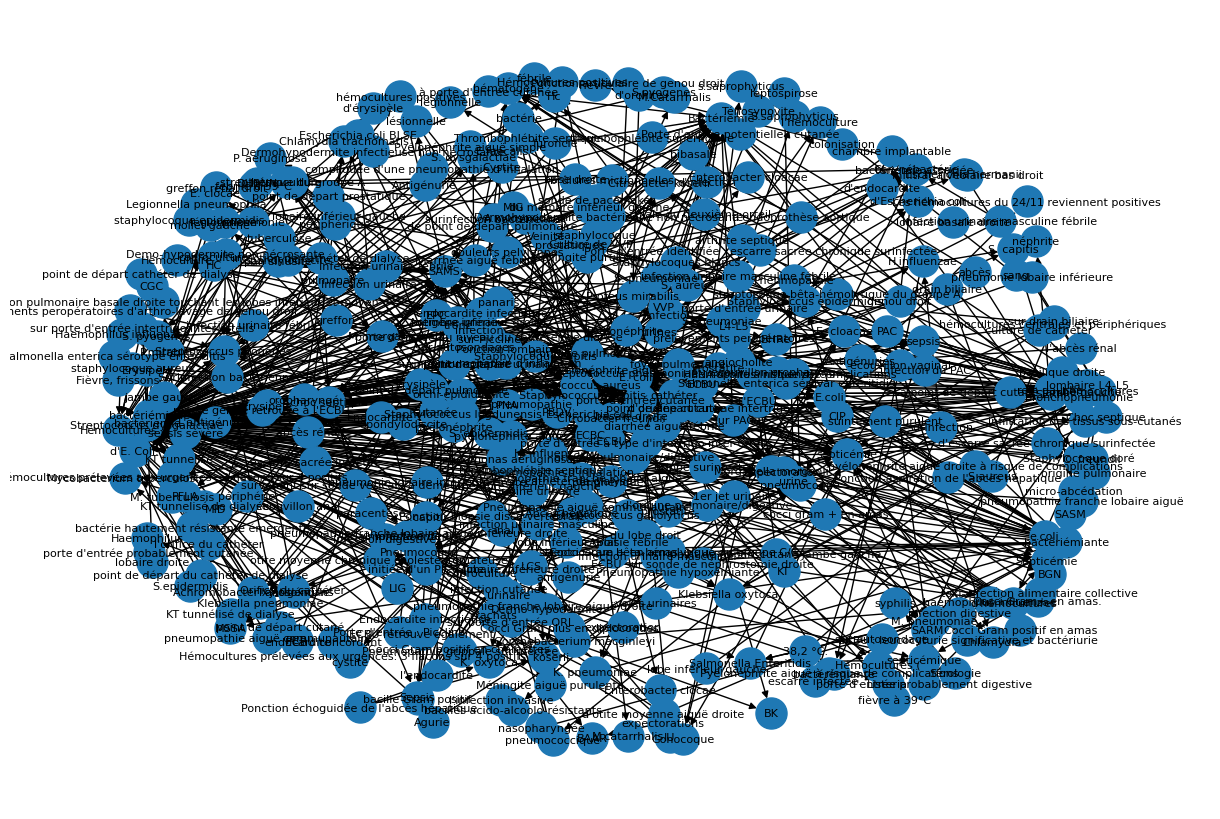

In [8]:
import matplotlib.pyplot as plt
import networkx as nx

G = nx.DiGraph()

for row in relations.itertuples():
    G.add_edge(
        row.source_text,
        row.target_text,
        relation=row.relation_type
    )

plt.figure(figsize=(12, 8))

pos = nx.spring_layout(G, k=0.5)  # layout force-directed

nx.draw(
    G,
    pos,
    with_labels=True,
    node_size=500,
    font_size=8
)

plt.show()

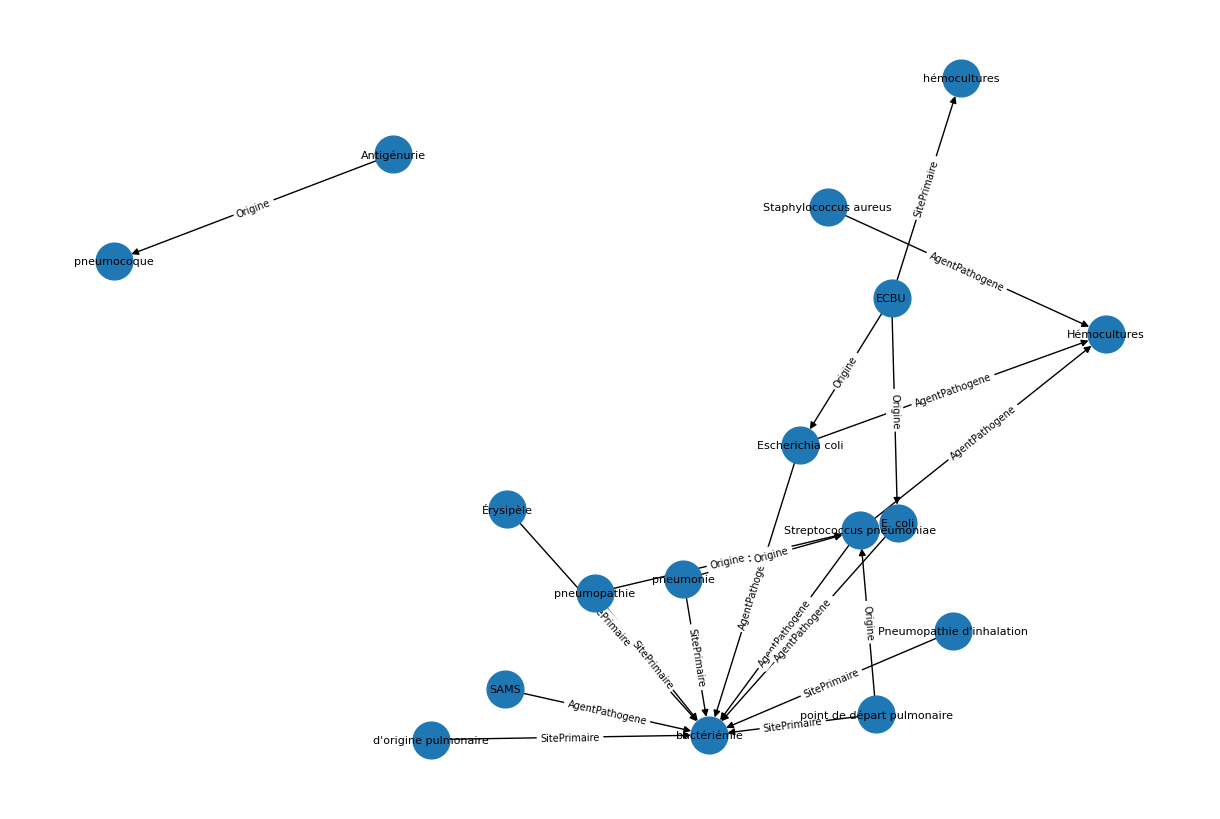

In [9]:
# garder uniquement les relations fréquentes
top_pairs = pair_counts.head(20)

G_small = nx.DiGraph()

for _, row in top_pairs.iterrows():
    G_small.add_edge(
        row["source_text"],
        row["target_text"],
        relation=row["relation_type"]
    )

plt.figure(figsize=(12, 8))
pos = nx.spring_layout(G_small, k=0.8)

nx.draw(G_small, pos, with_labels=True, node_size=700, font_size=8)

# ajouter labels des relations
edge_labels = {
    (u, v): d["relation"]
    for u, v, d in G_small.edges(data=True)
}

nx.draw_networkx_edge_labels(G_small, pos, edge_labels=edge_labels, font_size=7)

plt.show()